In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
import os
# Update this path to match your folder name exactly
PROJECT_PATH = '/content/drive/MyDrive/Colab Notebooks/deep_learning_project'
#PROJECT_PATH = '/content/drive/MyDrive/folders/deep_learning_project'


if os.path.exists(PROJECT_PATH):
    print(f"✅ Success! Found project at: {PROJECT_PATH}")
    os.chdir(PROJECT_PATH)
else:
    print(f"❌ Error: The path '{PROJECT_PATH}' does not exist.")

Mounted at /content/drive
✅ Success! Found project at: /content/drive/MyDrive/Colab Notebooks/deep_learning_project


In [ ]:
# --- CELL 1: Imports & Configuration ---

import torch
import time
import pandas as pd
import matplotlib.pyplot as plt
from src.data_utils import get_split_cifar10
from src.models import get_resnet18
from src.trainer import train_baseline, train_constrained, evaluate
from src.decompositions import SVDProjector, QRProjector, RSVDProjector, MagnitudePruningProjector, AdaptiveSVDProjector

# CONFIGURATION
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 64

# CIFAR-10 Specifics
CLASSES = 10
EPOCHS_EXPERT = 5
TASK_A_INDICES = list(range(5))
TASK_B_INDICES = list(range(5, 10))
CHECKPOINT_PATH = "checkpoints/task_a_expert_c10.pth"

TASK_B_EPOCHS_LIST = [2,4,6]

results = []
print("Configuration Complete. Single Dataset (CIFAR-10) Mode.")


Configuration Complete. Single Dataset (CIFAR-10) Mode.


In [ ]:
# --- CELL 2: Infrastructure & Baseline (Task A) ---
import os
os.makedirs("checkpoints", exist_ok=True)

print(f"\n=== Processing CIFAR-10 Expert ===")

# 1. Data Setup
print("--- Phase 1: Data Setup ---")
train_A, test_A, train_B, test_B = get_split_cifar10(BATCH_SIZE)

# 2. Train Expert
print(f"--- Phase 2: Training Expert Model (Task A) for {EPOCHS_EXPERT} epochs ---")
model_expert = get_resnet18(num_classes=CLASSES).to(DEVICE)
# Note: train_baseline now returns (model, history)
model_expert, history = train_baseline(model_expert, train_A, EPOCHS_EXPERT, DEVICE)
torch.save(model_expert.state_dict(), CHECKPOINT_PATH)

# 3. Evaluate
acc_A_initial = evaluate(model_expert, test_A, DEVICE, task_classes=TASK_A_INDICES)
print(f"Final Training Accuracy: {history['accuracy'][-1]:.2f}%")
print(f"CIFAR-10 Task A Expert Accuracy: {acc_A_initial:.2f}%")


=== Processing CIFAR-10 Expert ===
--- Phase 1: Data Setup ---
--- Phase 2: Training Expert Model (Task A) for 5 epochs ---
Starting Baseline Training (Task A) - Optimized Adam...
Epoch 1/5 | Loss: 0.8972 | Acc: 63.92% | LR: 0.000905
Epoch 2/5 | Loss: 0.6049 | Acc: 76.84% | LR: 0.000655
Epoch 3/5 | Loss: 0.4402 | Acc: 83.78% | LR: 0.000345
Epoch 4/5 | Loss: 0.2980 | Acc: 89.31% | LR: 0.000095
Epoch 5/5 | Loss: 0.1521 | Acc: 94.75% | LR: 0.000000
Final Training Accuracy: 94.75%
CIFAR-10 Task A Expert Accuracy: 87.88%


In [ ]:
# --- CELL 3: Experiment - Naive Baseline ---
print("\n--- Experiment: Naive Baseline ---")

train_A, test_A, train_B, test_B = get_split_cifar10(BATCH_SIZE)

# Initial Acc
model_ref = get_resnet18(num_classes=CLASSES).to(DEVICE)
model_ref.load_state_dict(torch.load(CHECKPOINT_PATH))
acc_A_initial = evaluate(model_ref, test_A, DEVICE, task_classes=TASK_A_INDICES)

for epochs_b in TASK_B_EPOCHS_LIST:
    print(f"\n   > Epochs: {epochs_b}")

    # Reset
    model_current = get_resnet18(num_classes=CLASSES).to(DEVICE)
    model_current.load_state_dict(torch.load(CHECKPOINT_PATH))

    # Train (Naive)
    model_current, history = train_baseline(model_current, train_B, epochs_b, DEVICE)

    # Metrics
    acc_A_final = evaluate(model_current, test_A, DEVICE, task_classes=TASK_A_INDICES)
    acc_B_final = evaluate(model_current, test_B, DEVICE, task_classes=TASK_B_INDICES)
    global_acc = (acc_A_final + acc_B_final) / 2
    forgetting = acc_A_initial - acc_A_final

    train_acc = history['accuracy'][-1]

    results.append({
        "Method": "Naive",
        "Hyperparam": "N/A",
        "Epochs": epochs_b,
        "Global Acc": global_acc,
        "Task A Acc (Retention)": acc_A_final,
        "Task B Acc (Plasticity)": acc_B_final,
        "Forgetting": forgetting,
        "Train Acc": train_acc,
        "Peak VRAM (MB)": 0,
        "Prep Time (s)": 0
    })
    print(f"Result: Global={global_acc:.2f}%, A={acc_A_final:.2f}%, B={acc_B_final:.2f}%, TrainAcc={train_acc:.2f}%")



--- Experiment: Naive Baseline ---

   > Epochs: 2
Starting Baseline Training (Task A) - Optimized Adam...
Epoch 1/2 | Loss: 0.5956 | Acc: 82.14% | LR: 0.000500
Epoch 2/2 | Loss: 0.2244 | Acc: 91.98% | LR: 0.000000
Result: Global=55.40%, A=23.28%, B=87.52%, TrainAcc=91.98%

   > Epochs: 4
Starting Baseline Training (Task A) - Optimized Adam...
Epoch 1/4 | Loss: 0.6010 | Acc: 81.97% | LR: 0.000854
Epoch 2/4 | Loss: 0.2719 | Acc: 90.38% | LR: 0.000500
Epoch 3/4 | Loss: 0.1682 | Acc: 94.01% | LR: 0.000146
Epoch 4/4 | Loss: 0.0726 | Acc: 97.54% | LR: 0.000000
Result: Global=61.05%, A=27.96%, B=94.14%, TrainAcc=97.54%

   > Epochs: 6
Starting Baseline Training (Task A) - Optimized Adam...
Epoch 1/6 | Loss: 0.5937 | Acc: 82.20% | LR: 0.000933
Epoch 2/6 | Loss: 0.2728 | Acc: 90.39% | LR: 0.000750
Epoch 3/6 | Loss: 0.1982 | Acc: 92.84% | LR: 0.000500
Epoch 4/6 | Loss: 0.1281 | Acc: 95.52% | LR: 0.000250
Epoch 5/6 | Loss: 0.0585 | Acc: 98.06% | LR: 0.000067
Epoch 6/6 | Loss: 0.0217 | Acc: 99.4

In [ ]:
# --- CELL EXPERIMENT: Standard SVD ---
print("\n--- Experiment: Standard SVD ---")

hyperparams = [0.95, 0.5]

train_A, test_A, train_B, test_B = get_split_cifar10(BATCH_SIZE)

# Reference
model_ref = get_resnet18(num_classes=CLASSES).to(DEVICE)
model_ref.load_state_dict(torch.load(CHECKPOINT_PATH))
acc_A_initial = evaluate(model_ref, test_A, DEVICE, task_classes=TASK_A_INDICES)

for hp in hyperparams:
    print(f"\n   >>> Threshold: {hp}")

    # Phase A: Heavy Computation (Run Once per Hyperparam)
    prep_time = 0
    peak_vram = 0

    # Initialize Projector with Hyperparameter
    # Inject variable 'hp' into the template
    projector = SVDProjector(rank_threshold=hp)


    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.empty_cache()

    start_time = time.time()
    projector.compute_subspaces(model_ref)

    if torch.cuda.is_available():
        peak_vram = torch.cuda.max_memory_allocated() / (1024 ** 2)
    prep_time = time.time() - start_time
    print(f"      Subspace computed in {prep_time:.2f}s")


    for epochs_b in TASK_B_EPOCHS_LIST:
        print(f"      > Epochs: {epochs_b}")

        # Reset
        model_current = get_resnet18(num_classes=CLASSES).to(DEVICE)
        model_current.load_state_dict(torch.load(CHECKPOINT_PATH))

        # Capture Start
        w_start = {name: param.detach().cpu().clone() for name, param in model_current.named_parameters()}

        # Eval Zero-Shot
        acc_A_zero = evaluate(model_current, test_A, DEVICE, task_classes=TASK_A_INDICES)
        compression_damage = acc_A_initial - acc_A_zero

        # Train Constrained
        model_current, history = train_constrained(model_current, train_B, epochs_b, DEVICE, projector)

        # Metrics
        acc_A_final = evaluate(model_current, test_A, DEVICE, task_classes=TASK_A_INDICES)
        acc_B_final = evaluate(model_current, test_B, DEVICE, task_classes=TASK_B_INDICES)

        global_acc = (acc_A_final + acc_B_final) / 2
        forgetting = acc_A_zero - acc_A_final
        train_acc = history['accuracy'][-1]

        drift_sq = 0.0
        for name, param in model_current.named_parameters():
                if name in w_start:
                    diff = param.detach().cpu() - w_start[name]
                    drift_sq += torch.sum(diff ** 2).item()
        weight_drift = drift_sq ** 0.5

        results.append({
            "Method": "SVD",
            "Hyperparam": hp,
            "Epochs": epochs_b,
            "Global Acc": global_acc,
            "Task A Acc (Retention)": acc_A_final,
            "Task B Acc (Plasticity)": acc_B_final,
            "Train Acc": train_acc,
            "Zero-Shot A": acc_A_zero,
            "Compression Damage": compression_damage,
            "Forgetting": forgetting,
            "Peak VRAM (MB)": peak_vram,
            "Weight Drift": weight_drift,
            "Prep Time (s)": prep_time
        })
        print(f"Result: Global={global_acc:.2f}%, A={acc_A_final:.2f}%, B={acc_B_final:.2f}%, Train={train_acc:.2f}%")



--- Experiment: Standard SVD ---

   >>> Threshold: 0.95
      Subspace computed in 0.24s
      > Epochs: 2
Starting Constrained Training (Method: SVDProjector)...
Epoch 1/2 | Loss: 0.6590 | Acc: 82.26%
Epoch 2/2 | Loss: 0.2648 | Acc: 90.63%
Result: Global=62.83%, A=37.60%, B=88.06%, Train=90.63%
      > Epochs: 4
Starting Constrained Training (Method: SVDProjector)...
Epoch 1/4 | Loss: 0.6519 | Acc: 82.29%
Epoch 2/4 | Loss: 0.2666 | Acc: 90.54%
Epoch 3/4 | Loss: 0.2083 | Acc: 92.68%
Epoch 4/4 | Loss: 0.1776 | Acc: 93.63%
Result: Global=64.63%, A=39.12%, B=90.14%, Train=93.63%
      > Epochs: 6
Starting Constrained Training (Method: SVDProjector)...
Epoch 1/6 | Loss: 0.6541 | Acc: 82.45%
Epoch 2/6 | Loss: 0.2679 | Acc: 90.45%
Epoch 3/6 | Loss: 0.2078 | Acc: 92.58%
Epoch 4/6 | Loss: 0.1777 | Acc: 93.72%
Epoch 5/6 | Loss: 0.1512 | Acc: 94.73%
Epoch 6/6 | Loss: 0.1265 | Acc: 95.48%
Result: Global=66.42%, A=40.78%, B=92.06%, Train=95.48%

   >>> Threshold: 0.5
      Subspace computed in 0

In [ ]:
# --- CELL EXPERIMENT: Adaptive SVD ---
print("\n--- Experiment: Adaptive SVD ---")

hyperparams = [0.2, 0.4] # mrr
trr_list =[0.95, 0.5] # Renamed from 'trr' to 'trr_list' to avoid confusion with loop variable 'trr'

train_A, test_A, train_B, test_B = get_split_cifar10(BATCH_SIZE)

# Reference
model_ref = get_resnet18(num_classes=CLASSES).to(DEVICE)
model_ref.load_state_dict(torch.load(CHECKPOINT_PATH))
acc_A_initial = evaluate(model_ref, test_A, DEVICE, task_classes=TASK_A_INDICES)

for hp in hyperparams:
  for trr in trr_list:
      print(f"\n   >>> MRR: {hp}")
      print(f"   >>> TRR: {trr}")

      # Phase A: Heavy Computation (Run Once per Hyperparam)
      prep_time = 0
      peak_vram = 0

      # Initialize Projector with Hyperparameter
      # Inject variable 'hp' into the template
      projector = AdaptiveSVDProjector(mrr=hp, trr=trr)


      if torch.cuda.is_available():
          torch.cuda.reset_peak_memory_stats()
          torch.cuda.empty_cache()

      start_time = time.time()
      projector.compute_subspaces(model_ref, test_A, DEVICE)

      if torch.cuda.is_available():
          peak_vram = torch.cuda.max_memory_allocated() / (1024 ** 2)
      prep_time = time.time() - start_time
      print(f"      Subspace computed in {prep_time:.2f}s")


      for epochs_b in TASK_B_EPOCHS_LIST:
          print(f"      > Epochs: {epochs_b}")

          # Reset
          model_current = get_resnet18(num_classes=CLASSES).to(DEVICE)
          model_current.load_state_dict(torch.load(CHECKPOINT_PATH))

          # Capture Start
          w_start = {name: param.detach().cpu().clone() for name, param in model_current.named_parameters()}

          # Eval Zero-Shot
          acc_A_zero = evaluate(model_current, test_A, DEVICE, task_classes=TASK_A_INDICES)
          compression_damage = acc_A_initial - acc_A_zero

          # Train Constrained
          model_current, history = train_constrained(model_current, train_B, epochs_b, DEVICE, projector)

          # Metrics
          acc_A_final = evaluate(model_current, test_A, DEVICE, task_classes=TASK_A_INDICES)
          acc_B_final = evaluate(model_current, test_B, DEVICE, task_classes=TASK_B_INDICES)

          global_acc = (acc_A_final + acc_B_final) / 2
          forgetting = acc_A_zero - acc_A_final
          train_acc = history['accuracy'][-1]

          drift_sq = 0.0
          for name, param in model_current.named_parameters():
                  if name in w_start:
                      diff = param.detach().cpu() - w_start[name]
                      drift_sq += torch.sum(diff ** 2).item()
          weight_drift = drift_sq ** 0.5

          results.append({
              "Method": "Adaptive SVD",
              "Hyperparam": f"MRR={hp}, TRR={trr}", # Changed to represent both MRR and TRR
              "Epochs": epochs_b,
              "Global Acc": global_acc,
              "Task A Acc (Retention)": acc_A_final,
              "Task B Acc (Plasticity)": acc_B_final,
              "Train Acc": train_acc,
              "Zero-Shot A": acc_A_zero,
              "Compression Damage": compression_damage,
              "Forgetting": forgetting,
              "Peak VRAM (MB)": peak_vram,
              "Weight Drift": weight_drift,
              "Prep Time (s)": prep_time
          })
          print(f"Result: Global={global_acc:.2f}%, A={acc_A_final:.2f}%, B={acc_B_final:.2f}%, Train={train_acc:.2f}%")



--- Experiment: Adaptive SVD ---

   >>> MRR: 0.2
   >>> TRR: 0.95
Adaptive SVD: Avg Importance = 0.3769 (over 13 matching layers)
      Subspace computed in 0.29s
      > Epochs: 2
Starting Constrained Training (Method: AdaptiveSVDProjector)...
Epoch 1/2 | Loss: 0.6544 | Acc: 82.45%
Epoch 2/2 | Loss: 0.2611 | Acc: 90.67%
Result: Global=70.82%, A=52.06%, B=89.58%, Train=90.67%
      > Epochs: 4
Starting Constrained Training (Method: AdaptiveSVDProjector)...
Epoch 1/4 | Loss: 0.6552 | Acc: 82.36%
Epoch 2/4 | Loss: 0.2631 | Acc: 90.56%
Epoch 3/4 | Loss: 0.2077 | Acc: 92.92%
Epoch 4/4 | Loss: 0.1707 | Acc: 93.95%
Result: Global=69.69%, A=50.10%, B=89.28%, Train=93.95%
      > Epochs: 6
Starting Constrained Training (Method: AdaptiveSVDProjector)...
Epoch 1/6 | Loss: 0.6565 | Acc: 82.40%
Epoch 2/6 | Loss: 0.2619 | Acc: 90.70%
Epoch 3/6 | Loss: 0.2055 | Acc: 92.95%
Epoch 4/6 | Loss: 0.1703 | Acc: 93.94%
Epoch 5/6 | Loss: 0.1410 | Acc: 95.03%
Epoch 6/6 | Loss: 0.1174 | Acc: 95.92%
Result: G

In [ ]:
# --- CELL EXPERIMENT: Randomized SVD ---
print("\n--- Experiment: Randomized SVD ---")

hyperparams = [0.2, 0.4, 0.6]

train_A, test_A, train_B, test_B = get_split_cifar10(BATCH_SIZE)

# Reference
model_ref = get_resnet18(num_classes=CLASSES).to(DEVICE)
model_ref.load_state_dict(torch.load(CHECKPOINT_PATH))
acc_A_initial = evaluate(model_ref, test_A, DEVICE, task_classes=TASK_A_INDICES)

for hp in hyperparams:
    print(f"\n   >>> Rank Fraction: {hp}")

    # Phase A: Heavy Computation (Run Once per Hyperparam)
    prep_time = 0
    peak_vram = 0

    # Initialize Projector with Hyperparameter
    # Inject variable 'hp' into the template
    projector = RSVDProjector(rank_fraction=hp, p=10, q=2)


    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.empty_cache()

    start_time = time.time()
    projector.compute_subspaces(model_ref)

    if torch.cuda.is_available():
        peak_vram = torch.cuda.max_memory_allocated() / (1024 ** 2)
    prep_time = time.time() - start_time
    print(f"      Subspace computed in {prep_time:.2f}s")


    for epochs_b in TASK_B_EPOCHS_LIST:
        print(f"      > Epochs: {epochs_b}")

        # Reset
        model_current = get_resnet18(num_classes=CLASSES).to(DEVICE)
        model_current.load_state_dict(torch.load(CHECKPOINT_PATH))

        # Capture Start
        w_start = {name: param.detach().cpu().clone() for name, param in model_current.named_parameters()}

        # Eval Zero-Shot
        acc_A_zero = evaluate(model_current, test_A, DEVICE, task_classes=TASK_A_INDICES)
        compression_damage = acc_A_initial - acc_A_zero

        # Train Constrained
        model_current, history = train_constrained(model_current, train_B, epochs_b, DEVICE, projector)

        # Metrics
        acc_A_final = evaluate(model_current, test_A, DEVICE, task_classes=TASK_A_INDICES)
        acc_B_final = evaluate(model_current, test_B, DEVICE, task_classes=TASK_B_INDICES)

        global_acc = (acc_A_final + acc_B_final) / 2
        forgetting = acc_A_zero - acc_A_final
        train_acc = history['accuracy'][-1]

        drift_sq = 0.0
        for name, param in model_current.named_parameters():
                if name in w_start:
                    diff = param.detach().cpu() - w_start[name]
                    drift_sq += torch.sum(diff ** 2).item()
        weight_drift = drift_sq ** 0.5

        results.append({
            "Method": "RSVD",
            "Hyperparam": hp,
            "Epochs": epochs_b,
            "Global Acc": global_acc,
            "Task A Acc (Retention)": acc_A_final,
            "Task B Acc (Plasticity)": acc_B_final,
            "Train Acc": train_acc,
            "Zero-Shot A": acc_A_zero,
            "Compression Damage": compression_damage,
            "Forgetting": forgetting,
            "Peak VRAM (MB)": peak_vram,
            "Weight Drift": weight_drift,
            "Prep Time (s)": prep_time
        })
        print(f"Result: Global={global_acc:.2f}%, A={acc_A_final:.2f}%, B={acc_B_final:.2f}%, Train={train_acc:.2f}%")



--- Experiment: Randomized SVD ---

   >>> Rank Fraction: 0.2
      Subspace computed in 0.13s
      > Epochs: 2
Starting Constrained Training (Method: RSVDProjector)...
Epoch 1/2 | Loss: 0.6236 | Acc: 82.46%
Epoch 2/2 | Loss: 0.2818 | Acc: 89.91%
Result: Global=73.00%, A=57.08%, B=88.92%, Train=89.91%
      > Epochs: 4
Starting Constrained Training (Method: RSVDProjector)...
Epoch 1/4 | Loss: 0.6094 | Acc: 82.97%
Epoch 2/4 | Loss: 0.2742 | Acc: 90.48%
Epoch 3/4 | Loss: 0.2188 | Acc: 92.20%
Epoch 4/4 | Loss: 0.1841 | Acc: 93.50%
Result: Global=70.52%, A=51.54%, B=89.50%, Train=93.50%
      > Epochs: 6
Starting Constrained Training (Method: RSVDProjector)...
Epoch 1/6 | Loss: 0.6209 | Acc: 82.58%
Epoch 2/6 | Loss: 0.2761 | Acc: 90.22%
Epoch 3/6 | Loss: 0.2249 | Acc: 92.12%
Epoch 4/6 | Loss: 0.1918 | Acc: 93.24%
Epoch 5/6 | Loss: 0.1641 | Acc: 94.34%
Epoch 6/6 | Loss: 0.1352 | Acc: 95.20%
Result: Global=71.51%, A=53.30%, B=89.72%, Train=95.20%

   >>> Rank Fraction: 0.4
      Subspace c

In [ ]:
# --- CELL EXPERIMENT: Pivoted QR ---
print("\n--- Experiment: Pivoted QR ---")
hyperparams = [0.2, 0.4, 0.6]

train_A, test_A, train_B, test_B = get_split_cifar10(BATCH_SIZE)

# Reference
model_ref = get_resnet18(num_classes=CLASSES).to(DEVICE)
model_ref.load_state_dict(torch.load(CHECKPOINT_PATH))
acc_A_initial = evaluate(model_ref, test_A, DEVICE, task_classes=TASK_A_INDICES)

for hp in hyperparams:
    print(f"\n   >>> Rank Fraction: {hp}")

    # Phase A: Heavy Computation (Run Once per Hyperparam)
    prep_time = 0
    peak_vram = 0

    # Initialize Projector with Hyperparameter
    # Inject variable 'hp' into the template
    projector = QRProjector(rank_fraction=hp)


    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.empty_cache()

    start_time = time.time()
    projector.compute_subspaces(model_ref, device=DEVICE)

    if torch.cuda.is_available():
        peak_vram = torch.cuda.max_memory_allocated() / (1024 ** 2)
    prep_time = time.time() - start_time
    print(f"      QR Subspace computed in {prep_time:.2f}s")


    for epochs_b in TASK_B_EPOCHS_LIST:
        print(f"      > Epochs: {epochs_b}")

        # Reset
        model_current = get_resnet18(num_classes=CLASSES).to(DEVICE)
        model_current.load_state_dict(torch.load(CHECKPOINT_PATH))

        # Capture Start
        w_start = {name: param.detach().cpu().clone() for name, param in model_current.named_parameters()}

        # Eval Zero-Shot
        acc_A_zero = evaluate(model_current, test_A, DEVICE, task_classes=TASK_A_INDICES)
        compression_damage = acc_A_initial - acc_A_zero

        # Train Constrained
        model_current, history = train_constrained(model_current, train_B, epochs_b, DEVICE, projector)

        # Metrics
        acc_A_final = evaluate(model_current, test_A, DEVICE, task_classes=TASK_A_INDICES)
        acc_B_final = evaluate(model_current, test_B, DEVICE, task_classes=TASK_B_INDICES)

        global_acc = (acc_A_final + acc_B_final) / 2
        forgetting = acc_A_zero - acc_A_final
        train_acc = history['accuracy'][-1]

        drift_sq = 0.0
        for name, param in model_current.named_parameters():
                if name in w_start:
                    diff = param.detach().cpu() - w_start[name]
                    drift_sq += torch.sum(diff ** 2).item()
        weight_drift = drift_sq ** 0.5

        results.append({
            "Method": "Pivoted QR",
            "Hyperparam": hp,
            "Epochs": epochs_b,
            "Global Acc": global_acc,
            "Task A Acc (Retention)": acc_A_final,
            "Task B Acc (Plasticity)": acc_B_final,
            "Train Acc": train_acc,
            "Zero-Shot A": acc_A_zero,
            "Compression Damage": compression_damage,
            "Forgetting": forgetting,
            "Peak VRAM (MB)": peak_vram,
            "Weight Drift": weight_drift,
            "Prep Time (s)": prep_time
        })
        print(f"Result: Global={global_acc:.2f}%, A={acc_A_final:.2f}%, B={acc_B_final:.2f}%, Train={train_acc:.2f}%")



--- Experiment: Pivoted QR ---

   >>> Rank Fraction: 0.2
Computing QR subspaces (Pivoted) using Scipy...
      QR Subspace computed in 1.93s
      > Epochs: 2
Starting Constrained Training (Method: QRProjector)...
Epoch 1/2 | Loss: 0.6180 | Acc: 82.79%
Epoch 2/2 | Loss: 0.2660 | Acc: 90.67%
Result: Global=63.24%, A=42.68%, B=83.80%, Train=90.67%
      > Epochs: 4
Starting Constrained Training (Method: QRProjector)...
Epoch 1/4 | Loss: 0.6202 | Acc: 82.76%
Epoch 2/4 | Loss: 0.2636 | Acc: 90.70%
Epoch 3/4 | Loss: 0.2098 | Acc: 92.59%
Epoch 4/4 | Loss: 0.1777 | Acc: 93.67%
Result: Global=63.82%, A=36.26%, B=91.38%, Train=93.67%
      > Epochs: 6
Starting Constrained Training (Method: QRProjector)...
Epoch 1/6 | Loss: 0.6184 | Acc: 83.05%
Epoch 2/6 | Loss: 0.2627 | Acc: 90.72%
Epoch 3/6 | Loss: 0.2110 | Acc: 92.56%
Epoch 4/6 | Loss: 0.1708 | Acc: 93.98%
Epoch 5/6 | Loss: 0.1411 | Acc: 95.04%
Epoch 6/6 | Loss: 0.1226 | Acc: 95.71%
Result: Global=61.20%, A=33.08%, B=89.32%, Train=95.71%

 

In [ ]:
# --- CELL EXPERIMENT: Global Magnitude Pruning ---
print("\n--- Experiment: Global Magnitude Pruning ---")
sparsity_targets = [0.2, 0.4, 0.6]

train_A, test_A, train_B, test_B = get_split_cifar10(BATCH_SIZE)

# Init Acc
model_ref = get_resnet18(num_classes=CLASSES).to(DEVICE)
model_ref.load_state_dict(torch.load(CHECKPOINT_PATH))
acc_A_initial = evaluate(model_ref, test_A, DEVICE, task_classes=TASK_A_INDICES)

for sp in sparsity_targets:
    print(f"\n   >>> Sparsity Target: {sp*100:.0f}%")

    for epochs_b in TASK_B_EPOCHS_LIST:
        print(f"      > Epochs: {epochs_b}")

        # Reset
        model_current = get_resnet18(num_classes=CLASSES).to(DEVICE)
        model_current.load_state_dict(torch.load(CHECKPOINT_PATH))

        # Pruning Setup
        projector = MagnitudePruningProjector(sparsity_target=sp)

        if torch.cuda.is_available():
            torch.cuda.reset_peak_memory_stats()
            torch.cuda.empty_cache()

        start_time = time.time()
        projector.compute_subspaces(model_current)
        prep_time = time.time() - start_time

        if torch.cuda.is_available():
            peak_vram = torch.cuda.max_memory_allocated() / (1024 ** 2)
        else:
            peak_vram = 0

        # Eval Zero-Shot
        acc_A_zero = evaluate(model_current, test_A, DEVICE, task_classes=TASK_A_INDICES)
        compression_damage = acc_A_initial - acc_A_zero
        print(f"Zero-Shot: {acc_A_zero:.2f}% (Damage: {compression_damage:.2f}%)")

        # Drift Start
        w_start = {name: param.detach().cpu().clone() for name, param in model_current.named_parameters()}

        # Train
        model_current, history = train_constrained(model_current, train_B, epochs_b, DEVICE, projector)

        # Metrics
        acc_A_final = evaluate(model_current, test_A, DEVICE, task_classes=TASK_A_INDICES)
        acc_B_final = evaluate(model_current, test_B, DEVICE, task_classes=TASK_B_INDICES)

        global_acc = (acc_A_final + acc_B_final) / 2
        forgetting = acc_A_zero - acc_A_final
        train_acc = history['accuracy'][-1]

        drift_sq = 0.0
        for name, param in model_current.named_parameters():
                if name in w_start:
                    diff = param.detach().cpu() - w_start[name]
                    drift_sq += torch.sum(diff ** 2).item()
        weight_drift = drift_sq ** 0.5

        results.append({
            "Method": "Pruning",
            "Hyperparam": sp,
            "Epochs": epochs_b,
            "Global Acc": global_acc,
            "Task A Acc (Retention)": acc_A_final,
            "Task B Acc (Plasticity)": acc_B_final,
            "Train Acc": train_acc,
            "Zero-Shot A": acc_A_zero,
            "Compression Damage": compression_damage,
            "Forgetting": forgetting,
            "Peak VRAM (MB)": peak_vram,
            "Weight Drift": weight_drift,
            "Prep Time (s)": prep_time
        })
        print(f"Result: Global={global_acc:.2f}%, A={acc_A_final:.2f}%, B={acc_B_final:.2f}%, Train={train_acc:.2f}%")



--- Experiment: Global Magnitude Pruning ---

   >>> Sparsity Target: 20%
      > Epochs: 2
Pruning 21 layers with Global Sparsity 20.0%...
Global Sparsity Achieved: 20.00%
Zero-Shot: 87.90% (Damage: -0.02%)
Starting Constrained Training (Method: MagnitudePruningProjector)...
Epoch 1/2 | Loss: 0.6038 | Acc: 82.32%
Epoch 2/2 | Loss: 0.2828 | Acc: 89.86%
Result: Global=60.38%, A=31.50%, B=89.26%, Train=89.86%
      > Epochs: 4
Pruning 21 layers with Global Sparsity 20.0%...
Global Sparsity Achieved: 20.00%
Zero-Shot: 87.90% (Damage: -0.02%)
Starting Constrained Training (Method: MagnitudePruningProjector)...
Epoch 1/4 | Loss: 0.6111 | Acc: 81.78%
Epoch 2/4 | Loss: 0.2857 | Acc: 89.68%
Epoch 3/4 | Loss: 0.2202 | Acc: 92.15%
Epoch 4/4 | Loss: 0.1928 | Acc: 93.30%
Result: Global=58.95%, A=26.90%, B=91.00%, Train=93.30%
      > Epochs: 6
Pruning 21 layers with Global Sparsity 20.0%...
Global Sparsity Achieved: 20.00%
Zero-Shot: 87.90% (Damage: -0.02%)
Starting Constrained Training (Method: 

In [ ]:
# --- CELL: View Results ---
df_results = pd.DataFrame(results)
print("\n=== Final Results Summary ===")
print(df_results)

df_results.to_csv("main_experiment_results_inbar_220226.csv", index=False)



=== Final Results Summary ===
          Method         Hyperparam  Epochs  Global Acc  \
0          Naive                N/A       2       55.40   
1          Naive                N/A       4       61.05   
2          Naive                N/A       6       62.15   
3            SVD               0.95       2       62.83   
4            SVD               0.95       4       64.63   
5            SVD               0.95       6       66.42   
6            SVD                0.5       2       69.57   
7            SVD                0.5       4       72.68   
8            SVD                0.5       6       72.86   
9   Adaptive SVD  MRR=0.2, TRR=0.95       2       70.82   
10  Adaptive SVD  MRR=0.2, TRR=0.95       4       69.69   
11  Adaptive SVD  MRR=0.2, TRR=0.95       6       67.67   
12  Adaptive SVD   MRR=0.2, TRR=0.5       2       71.73   
13  Adaptive SVD   MRR=0.2, TRR=0.5       4       67.95   
14  Adaptive SVD   MRR=0.2, TRR=0.5       6       69.73   
15  Adaptive SVD  MRR=0.4

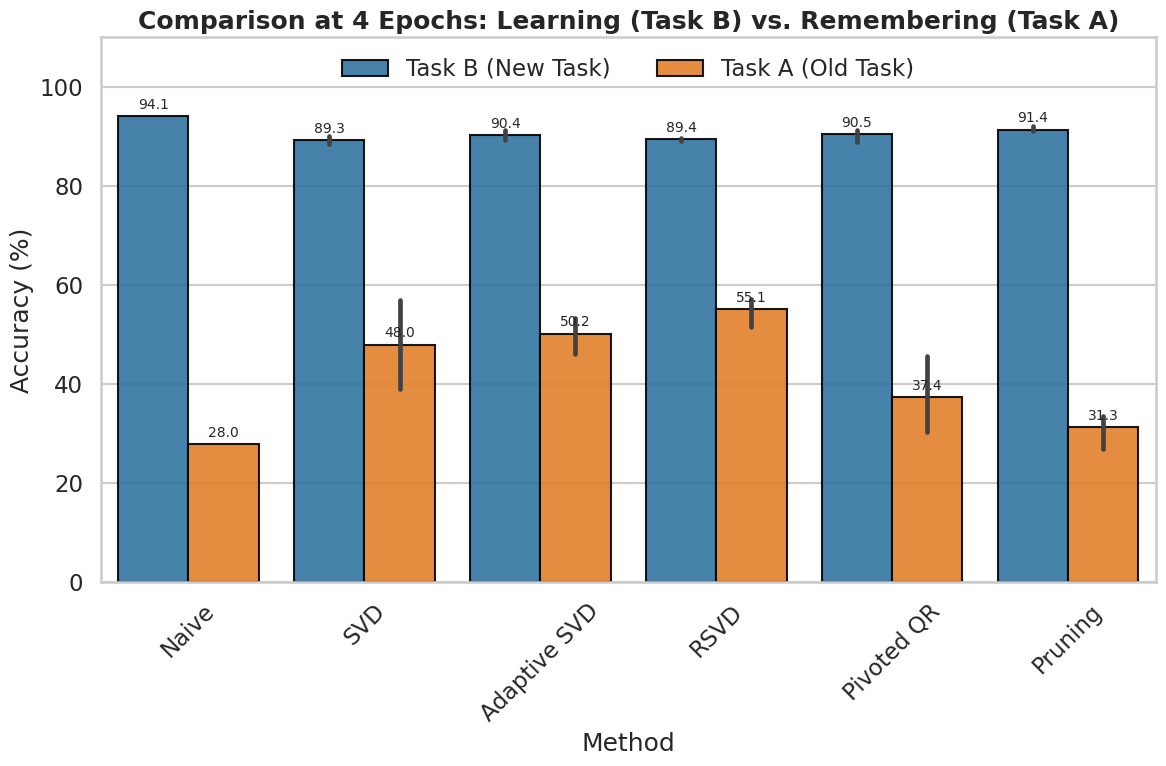

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Load and Prepare Data ---
df = pd.read_csv('main_experiment_results_inbar_220226.csv')

# Filter for exactly 4 Epochs
df_plot = df[df['Epochs'] == 4].copy()

# Melt the dataframe to get "Side-by-Side" bars easily in Seaborn
# This transforms columns into rows: (Method, Task Type, Accuracy)
df_melted = df_plot.melt(
    id_vars=['Method'],
    value_vars=['Task B Acc (Plasticity)', 'Task A Acc (Retention)'],
    var_name='Metric',
    value_name='Accuracy'
)

# Rename the metrics for the legend to be cleaner
df_melted['Metric'] = df_melted['Metric'].replace({
    'Task B Acc (Plasticity)': 'Task B (New Task)',
    'Task A Acc (Retention)': 'Task A (Old Task)'
})

# Set plot style
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams['font.family'] = 'sans-serif'

# --- Plot ---
plt.figure(figsize=(12, 8))

ax = sns.barplot(
    data=df_melted,
    x='Method',
    y='Accuracy',
    hue='Metric',
    palette=['#1f77b4', '#ff7f0e'], # Blue (Left) for Task B, Orange (Right) for Task A
    edgecolor="black",
    alpha=0.9
)

# Formatting
plt.title("Comparison at 4 Epochs: Learning (Task B) vs. Remembering (Task A)", fontweight='bold')
plt.ylabel("Accuracy (%)")
plt.xlabel("Method")
plt.ylim(0, 110) # Little extra room for legend
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.00), ncol=2, frameon=False)
plt.xticks(rotation=45)

# Add values on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3, fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
# --- CELL: View Results ---
df_results = pd.DataFrame(results)
print("\n=== Final Results Summary ===")
print(df_results)

df_results.to_csv("main_experiment_results_inbar_220226.csv", index=False)



=== Final Results Summary ===
          Method         Hyperparam  Epochs  Global Acc  \
0          Naive                N/A       2       55.40   
1          Naive                N/A       4       61.05   
2          Naive                N/A       6       62.15   
3            SVD               0.95       2       62.83   
4            SVD               0.95       4       64.63   
5            SVD               0.95       6       66.42   
6            SVD                0.5       2       69.57   
7            SVD                0.5       4       72.68   
8            SVD                0.5       6       72.86   
9   Adaptive SVD  MRR=0.2, TRR=0.95       2       70.82   
10  Adaptive SVD  MRR=0.2, TRR=0.95       4       69.69   
11  Adaptive SVD  MRR=0.2, TRR=0.95       6       67.67   
12  Adaptive SVD   MRR=0.2, TRR=0.5       2       71.73   
13  Adaptive SVD   MRR=0.2, TRR=0.5       4       67.95   
14  Adaptive SVD   MRR=0.2, TRR=0.5       6       69.73   
15  Adaptive SVD  MRR=0.4

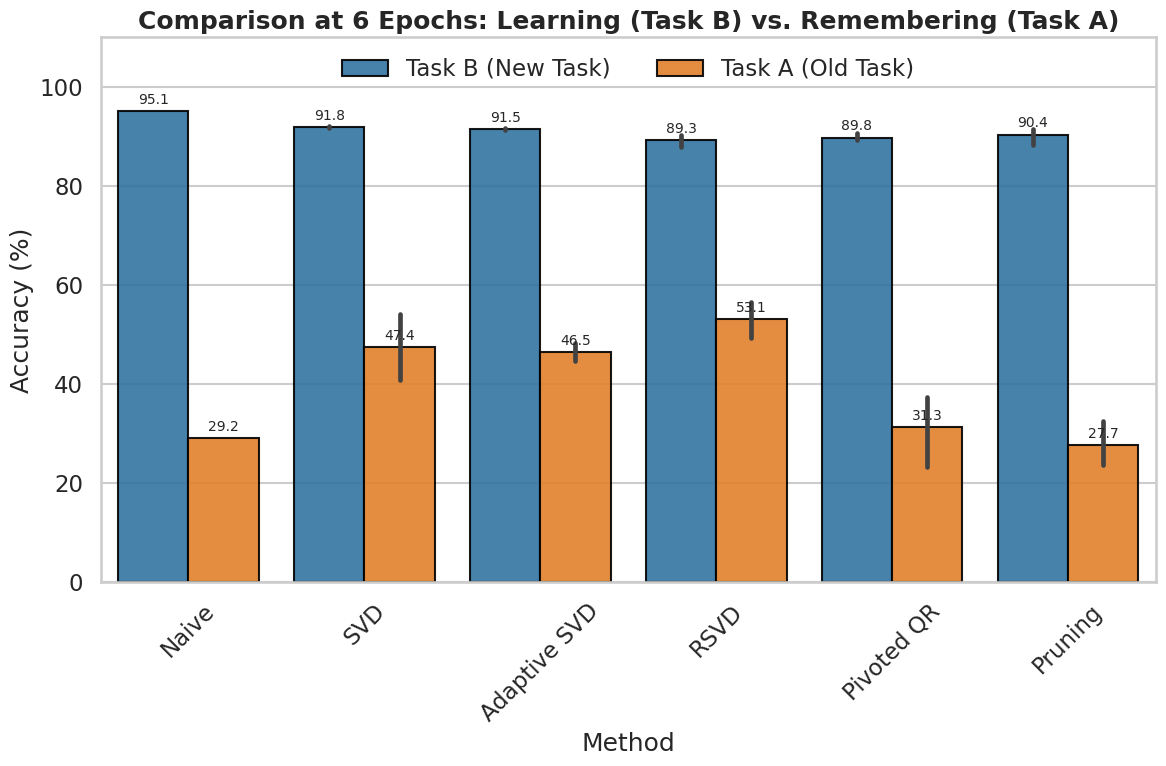

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Load and Prepare Data ---
df = pd.read_csv('main_experiment_results_inbar_220226.csv')

# Filter for exactly 6 Epochs
df_plot = df[df['Epochs'] == 6].copy()

# Melt the dataframe to get "Side-by-Side" bars easily in Seaborn
# This transforms columns into rows: (Method, Task Type, Accuracy)
df_melted = df_plot.melt(
    id_vars=['Method'],
    value_vars=['Task B Acc (Plasticity)', 'Task A Acc (Retention)'],
    var_name='Metric',
    value_name='Accuracy'
)

# Rename the metrics for the legend to be cleaner
df_melted['Metric'] = df_melted['Metric'].replace({
    'Task B Acc (Plasticity)': 'Task B (New Task)',
    'Task A Acc (Retention)': 'Task A (Old Task)'
})

# Set plot style
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams['font.family'] = 'sans-serif'

# --- Plot ---
plt.figure(figsize=(12, 8))

ax = sns.barplot(
    data=df_melted,
    x='Method',
    y='Accuracy',
    hue='Metric',
    palette=['#1f77b4', '#ff7f0e'], # Blue (Left) for Task B, Orange (Right) for Task A
    edgecolor="black",
    alpha=0.9
)

# Formatting
plt.title("Comparison at 6 Epochs: Learning (Task B) vs. Remembering (Task A)", fontweight='bold')
plt.ylabel("Accuracy (%)")
plt.xlabel("Method")
plt.ylim(0, 110) # Little extra room for legend
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.00), ncol=2, frameon=False)
plt.xticks(rotation=45)

# Add values on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3, fontsize=10)

plt.tight_layout()
plt.show()

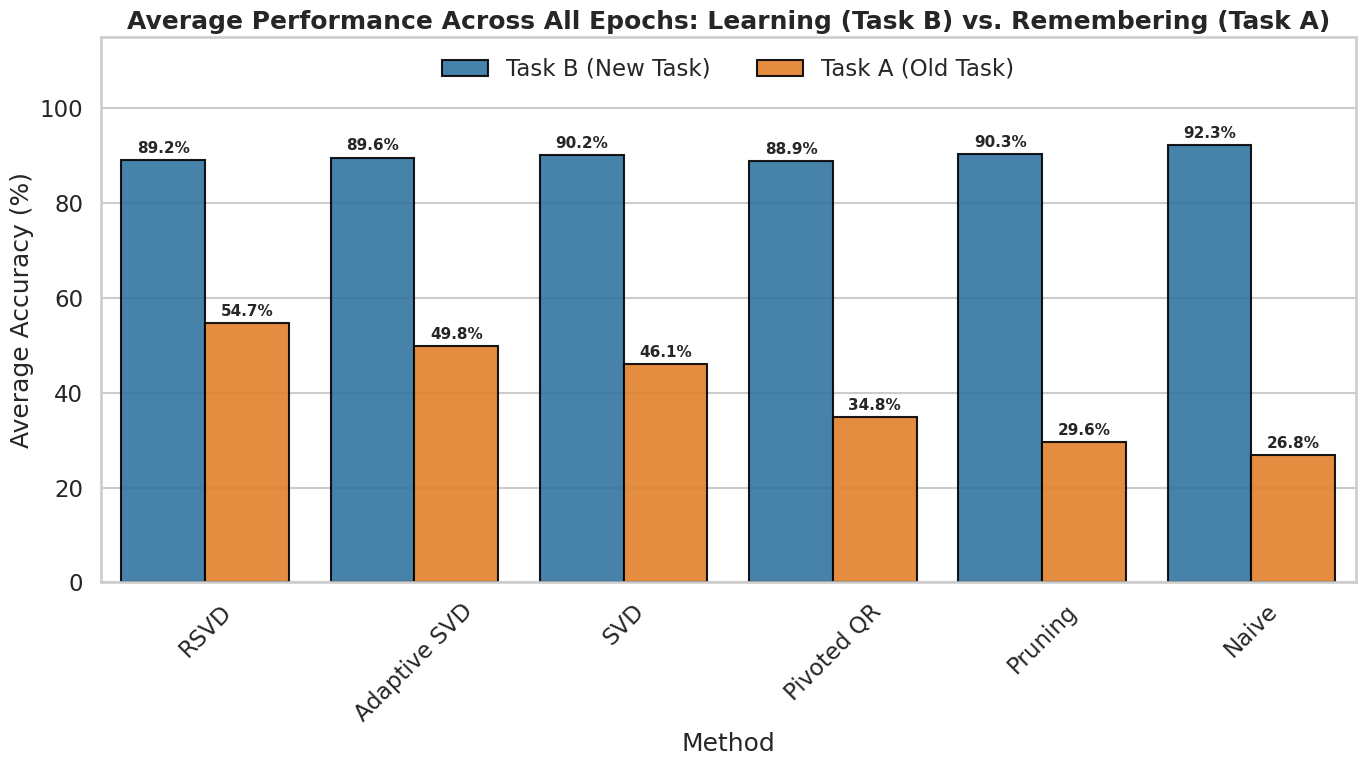

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Load and Prepare Data ---
df = pd.read_csv('main_experiment_results_inbar_220226.csv')


# Group by Method and calculate the mean across all epochs
df_avg = df.groupby('Method')[['Task B Acc (Plasticity)', 'Task A Acc (Retention)']].mean().reset_index()

# Melt the dataframe to get "Side-by-Side" bars
df_melted = df_avg.melt(
    id_vars=['Method'],
    value_vars=['Task B Acc (Plasticity)', 'Task A Acc (Retention)'],
    var_name='Metric',
    value_name='Accuracy'
)

# Rename the metrics for the legend
df_melted['Metric'] = df_melted['Metric'].replace({
    'Task B Acc (Plasticity)': 'Task B (New Task)',
    'Task A Acc (Retention)': 'Task A (Old Task)'
})

# Set plot style
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams['font.family'] = 'sans-serif'

# --- 2. Plot ---
plt.figure(figsize=(14, 8))

# Sorting methods by Retention (Task A) for a cleaner leaderboard look
method_order = df_avg.sort_values('Task A Acc (Retention)', ascending=False)['Method']

ax = sns.barplot(
    data=df_melted,
    x='Method',
    y='Accuracy',
    hue='Metric',
    order=method_order,
    palette=['#1f77b4', '#ff7f0e'], # Blue for Task B, Orange for Task A
    edgecolor="black",
    alpha=0.9
)

# Formatting
plt.title("Average Performance Across All Epochs: Learning (Task B) vs. Remembering (Task A)", fontweight='bold')
plt.ylabel("Average Accuracy (%)")
plt.xlabel("Method")
plt.ylim(0, 115)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.0), ncol=2, frameon=False)
plt.xticks(rotation=45)

# Add values on top of every bar (Robust loop)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

/tmp/ipython-input-3339553095.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(


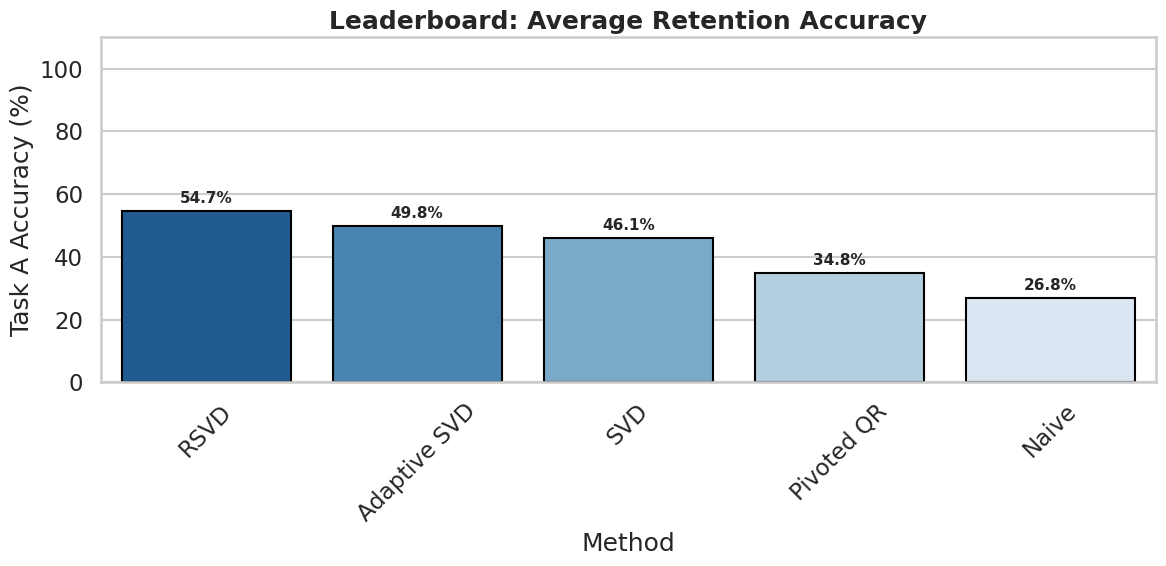

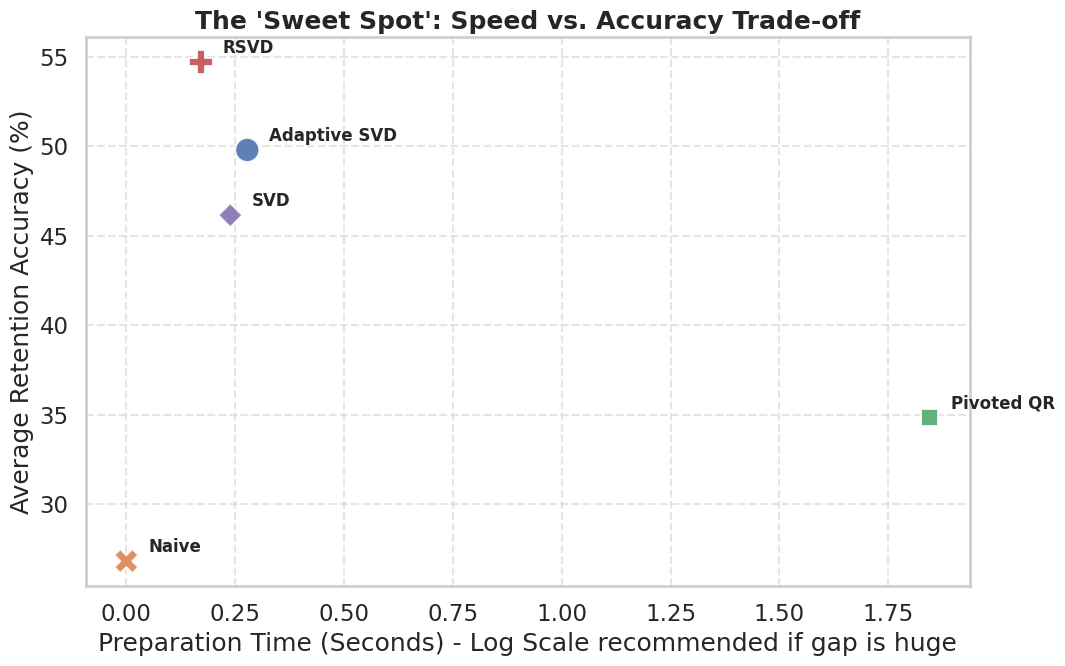

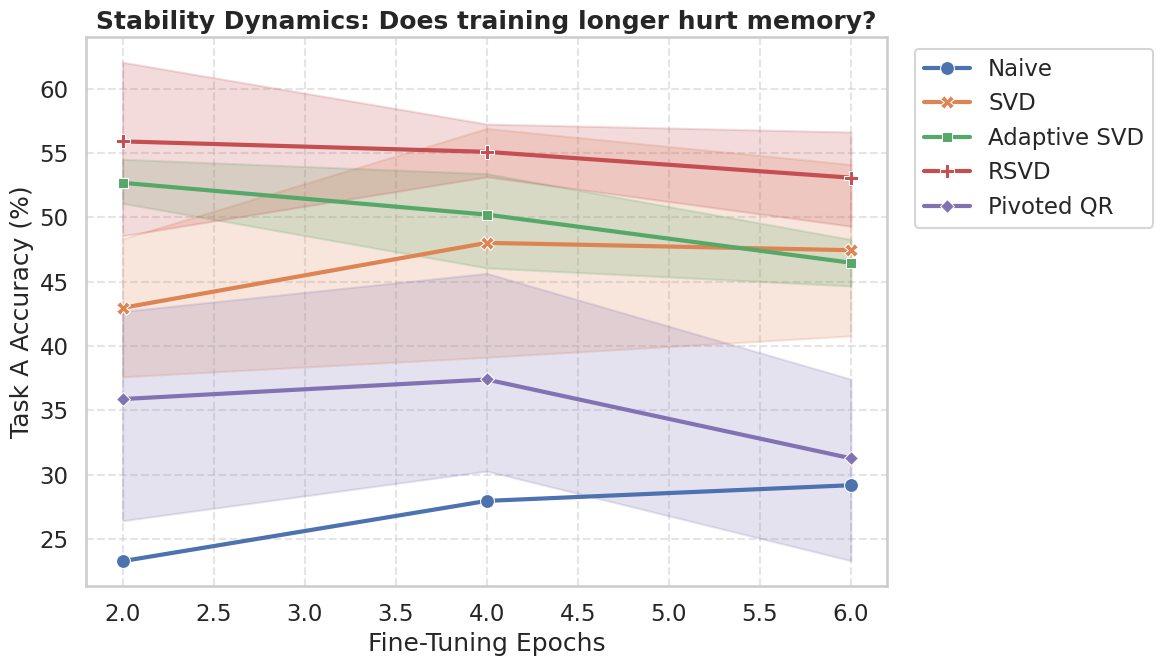

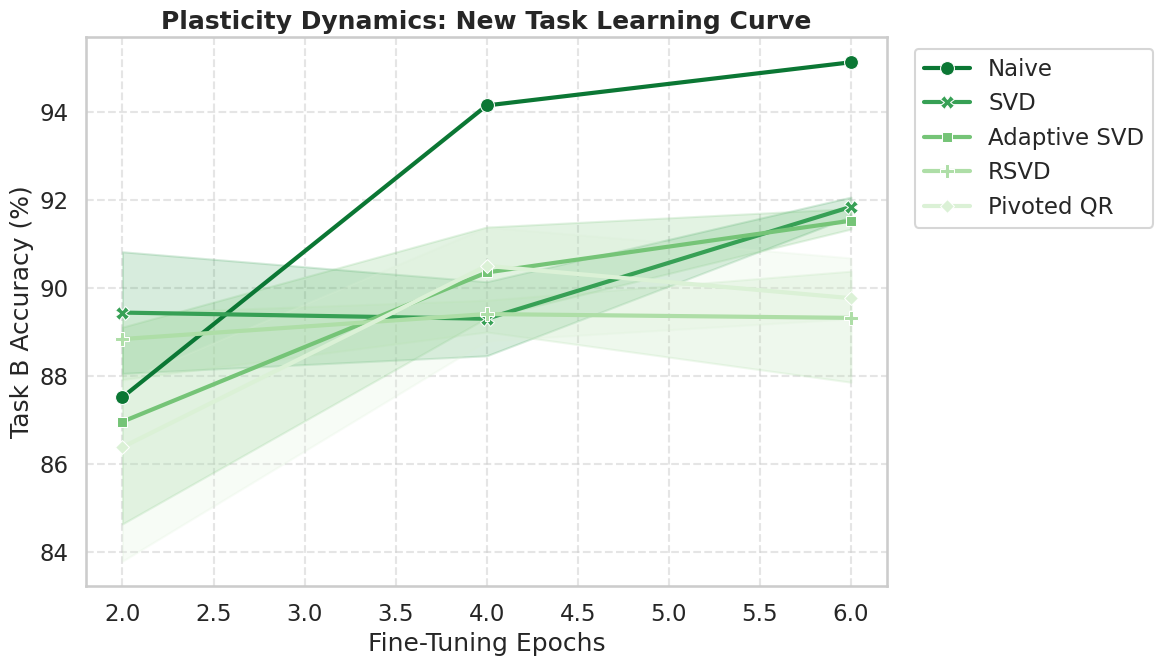

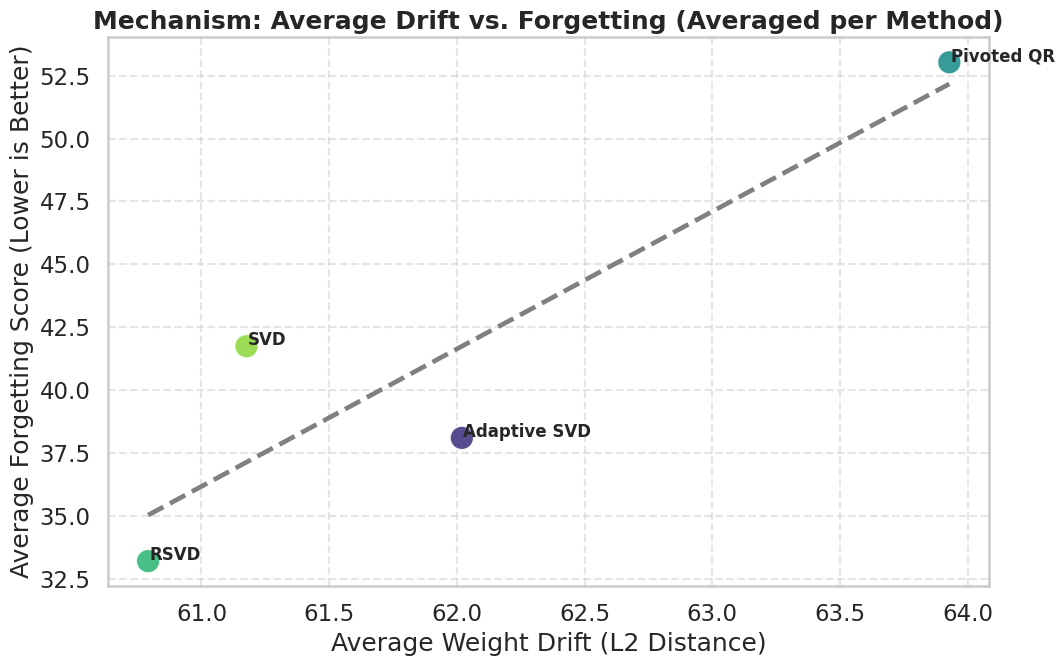

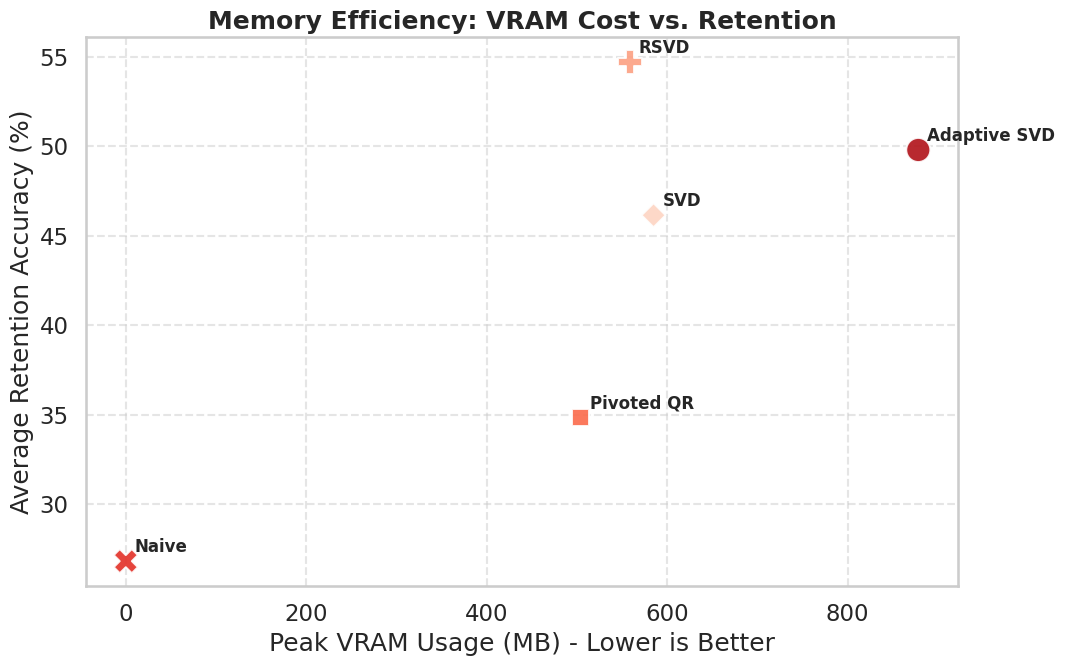

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Load and Prepare Data ---
df = pd.read_csv('main_experiment_results_inbar_220226.csv')

# Filter out the 'Pruning' method as requested
df = df[df['Method'] != 'Pruning'].copy()

# Ensure Epochs is treated as a number for line plots
df['Epochs'] = pd.to_numeric(df['Epochs'])

# Set professional plot style
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams['font.family'] = 'sans-serif'

# ==========================================
# Plot 1: Retention Leaderboard (Bar Chart)
# ==========================================
plt.figure(figsize=(12, 6))
# Calculate average retention per method to determine the order
df_res = df.groupby('Method')['Task A Acc (Retention)'].mean().sort_values(ascending=False).reset_index()

ax1 = sns.barplot(
    data=df_res,
    x="Method",
    y="Task A Acc (Retention)",
    palette="Blues_r",
    edgecolor="black"
)

# ROBUST LABELING: Loop through each bar patch individually
for p in ax1.patches:
    ax1.annotate(f'{p.get_height():.1f}%',
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center',
                 xytext=(0, 9),
                 textcoords='offset points',
                 fontweight='bold', fontsize=11)

plt.title("Leaderboard: Average Retention Accuracy", fontweight='bold')
plt.ylabel("Task A Accuracy (%)")
plt.ylim(0, 110)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ==========================================
# Plot 2: The "Sweet Spot" (Time vs. Retention)
# ==========================================
# We use the average performance to simplify the scatter plot
df_avg = df.groupby('Method')[['Prep Time (s)', 'Task A Acc (Retention)']].mean().reset_index()

plt.figure(figsize=(11, 7))
sns.scatterplot(
    data=df_avg,
    x="Prep Time (s)",
    y="Task A Acc (Retention)",
    hue="Method",
    style="Method",
    s=300, # Large markers
    palette="deep",
    alpha=0.9,
    legend=False # Labels are added directly to points
)

# Label points
for i in range(df_avg.shape[0]):
    plt.text(
        df_avg['Prep Time (s)'].iloc[i] + 0.05,
        df_avg['Task A Acc (Retention)'].iloc[i] + 0.5,
        df_avg['Method'].iloc[i],
        fontsize=12,
        weight='bold'
    )

plt.title("The 'Sweet Spot': Speed vs. Accuracy Trade-off", fontweight='bold')
plt.xlabel("Preparation Time (Seconds) - Log Scale recommended if gap is huge")
plt.ylabel("Average Retention Accuracy (%)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ==========================================
# Plot 3: Retention Trend (Line Plot)
# ==========================================
plt.figure(figsize=(12, 7))
sns.lineplot(
    data=df,
    x="Epochs",
    y="Task A Acc (Retention)",
    hue="Method",
    style="Method",
    markers=True,
    dashes=False,
    palette="deep",
    linewidth=3,
    markersize=10
)
plt.title("Stability Dynamics: Does training longer hurt memory?", fontweight='bold')
plt.ylabel("Task A Accuracy (%)")
plt.xlabel("Fine-Tuning Epochs")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ==========================================
# Plot 4: Plasticity Trend (Line Plot)
# ==========================================
plt.figure(figsize=(12, 7))
sns.lineplot(
    data=df,
    x="Epochs",
    y="Task B Acc (Plasticity)",
    hue="Method",
    style="Method",
    markers=True,
    dashes=False,
    palette="Greens_r",
    linewidth=3,
    markersize=10
)
plt.title("Plasticity Dynamics: New Task Learning Curve", fontweight='bold')
plt.ylabel("Task B Accuracy (%)")
plt.xlabel("Fine-Tuning Epochs")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ==========================================
# Plot 5: Mechanism Check (Drift vs. Forgetting) - Averaged per Method
# ==========================================

# Calculate mean Weight Drift and Forgetting for each Method
df_avg_drift_forgetting = df.groupby('Method')[['Weight Drift', 'Forgetting']].mean().reset_index()

plt.figure(figsize=(11, 7))
sns.scatterplot(
    data=df_avg_drift_forgetting,
    x="Weight Drift",
    y="Forgetting",
    hue="Method",
    s=300, # Increased size for clarity with fewer points
    palette="viridis",
    alpha=0.9,
    legend=False # Labels will be added directly
)

# Label points
for i in range(df_avg_drift_forgetting.shape[0]):
    plt.text(
        df_avg_drift_forgetting['Weight Drift'].iloc[i] + 0.005, # Adjust offset for labels
        df_avg_drift_forgetting['Forgetting'].iloc[i] + 0.05,
        df_avg_drift_forgetting['Method'].iloc[i],
        fontsize=12,
        weight='bold'
    )


# Add Trend Line on the averaged data
sns.regplot(
    data=df_avg_drift_forgetting,
    x="Weight Drift",
    y="Forgetting",
    scatter=False,
    color="grey",
    line_kws={"linestyle": "--", "label": "Correlation Trend"},
    ci=None # Remove the shadow (confidence interval)
)

plt.title("Mechanism: Average Drift vs. Forgetting (Averaged per Method)", fontweight='bold')
plt.xlabel("Average Weight Drift (L2 Distance)")
plt.ylabel("Average Forgetting Score (Lower is Better)")
# No need for legend as labels are directly on points
# plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ==========================================
# Plot 6: VRAM Efficiency
# ==========================================
df_vram_avg = df.groupby('Method')[['Peak VRAM (MB)', 'Task A Acc (Retention)']].mean().reset_index()

plt.figure(figsize=(11, 7))
sns.scatterplot(
    data=df_vram_avg,
    x="Peak VRAM (MB)",
    y="Task A Acc (Retention)",
    hue="Method",
    style="Method",
    s=300,
    palette="Reds_r",
    alpha=0.9,
    legend=False
)

for i in range(df_vram_avg.shape[0]):
    plt.text(
        df_vram_avg['Peak VRAM (MB)'].iloc[i] + 10,
        df_vram_avg['Task A Acc (Retention)'].iloc[i] + 0.5,
        df_vram_avg['Method'].iloc[i],
        fontsize=12,
        weight='bold'
    )

plt.title("Memory Efficiency: VRAM Cost vs. Retention", fontweight='bold')
plt.xlabel("Peak VRAM Usage (MB) - Lower is Better")
plt.ylabel("Average Retention Accuracy (%)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

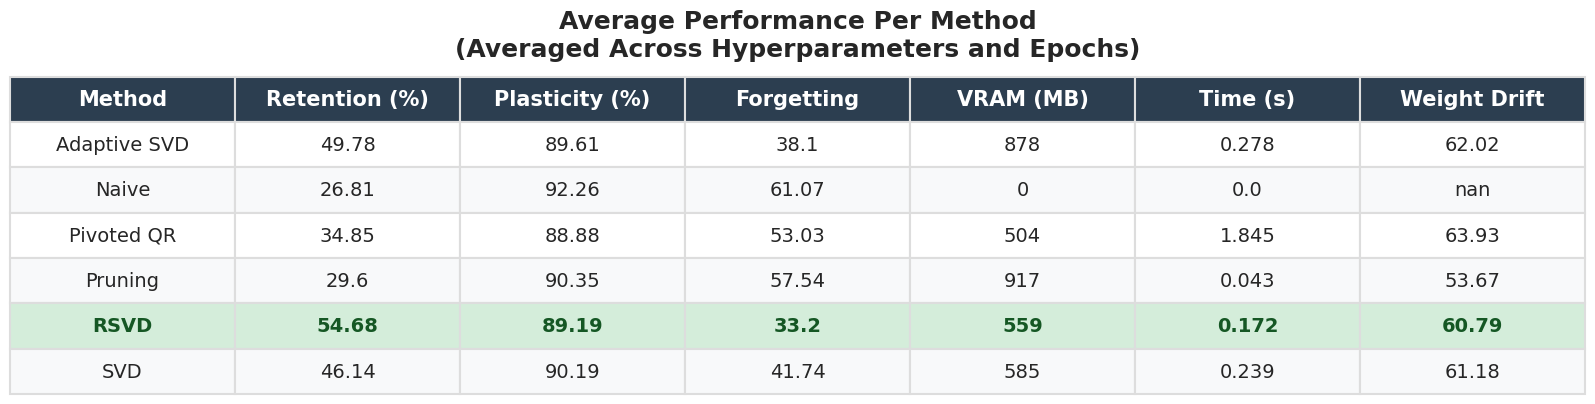

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Load and Prepare Data ---
df = pd.read_csv('main_experiment_results_inbar_220226.csv')

# Group by Method only, then calculate the mean across all hyperparameters and epochs
metrics = [
    'Task A Acc (Retention)', 'Task B Acc (Plasticity)', 'Forgetting',
    'Peak VRAM (MB)', 'Prep Time (s)', 'Weight Drift'
]
df_avg_per_method = df.groupby('Method')[metrics].mean().reset_index()

# Sort for better readability
df_avg_per_method = df_avg_per_method.sort_values(by='Method').reset_index(drop=True)

# Select and Rename Columns
cols_map = {
    'Method': 'Method',
    'Task A Acc (Retention)': 'Retention (%)',
    'Task B Acc (Plasticity)': 'Plasticity (%)',
    'Forgetting': 'Forgetting',
    'Peak VRAM (MB)': 'VRAM (MB)',
    'Prep Time (s)': 'Time (s)',
    'Weight Drift': 'Weight Drift'
}

df_view = df_avg_per_method.rename(columns=cols_map)

# Formatting numbers
df_view['Retention (%)'] = df_view['Retention (%)'].round(2)
df_view['Plasticity (%)'] = df_view['Plasticity (%)'].round(2)
df_view['Forgetting'] = df_view['Forgetting'].round(2)
df_view['VRAM (MB)'] = df_view['VRAM (MB)'].round(0).fillna(0).astype(int)
df_view['Time (s)'] = df_view['Time (s)'].round(3)
df_view['Weight Drift'] = df_view['Weight Drift'].round(2)

# --- Create Visual Table ---
# Reduced the constant added to the height to minimize empty space
fig, ax = plt.subplots(figsize=(16, len(df_view) * 0.6 + 0.5))
ax.axis('off')

# Prepare data list
header = df_view.columns.to_list()
data = df_view.values.tolist()
table_content = [header] + data

# Draw Table using bbox to force it to fill the axis without excess margins
table = ax.table(
    cellText=table_content,
    colLabels=None,
    cellLoc='center',
    loc='center',
    bbox=[0, 0, 1, 1]
)

# Styling - Bigger and cleaner
table.auto_set_font_size(False)
table.set_fontsize(14)

# --- Row Specific Styling (Dynamic for all rows) ---
for i in range(len(table_content)):
    is_rsvd = (table_content[i][0] == 'RSVD')

    for j in range(len(header)):
        cell = table[(i, j)]
        cell.set_edgecolor('#dddddd')

        if i == 0:
            # Header row styling
            cell.set_facecolor('#2c3e50')
            cell.set_text_props(color='white', weight='bold', fontsize=15)
        elif is_rsvd:
            # Highlight RSVD row
            cell.set_facecolor('#d4edda')
            cell.set_text_props(color='#155724', weight='bold')
        elif i % 2 == 1:
            # Odd data rows
            cell.set_facecolor('#ffffff')
        else:
            # Even data rows
            cell.set_facecolor('#f8f9fa')

# Adjusted title y-parameter and added pad to reduce space under the title
plt.title("Average Performance Per Method\n(Averaged Across Hyperparameters and Epochs)",
          fontweight='bold', fontsize=18, y=1.0, pad=15)

# Reduced padding in tight_layout to eliminate excess external space
plt.tight_layout(pad=0.5)
plt.show()

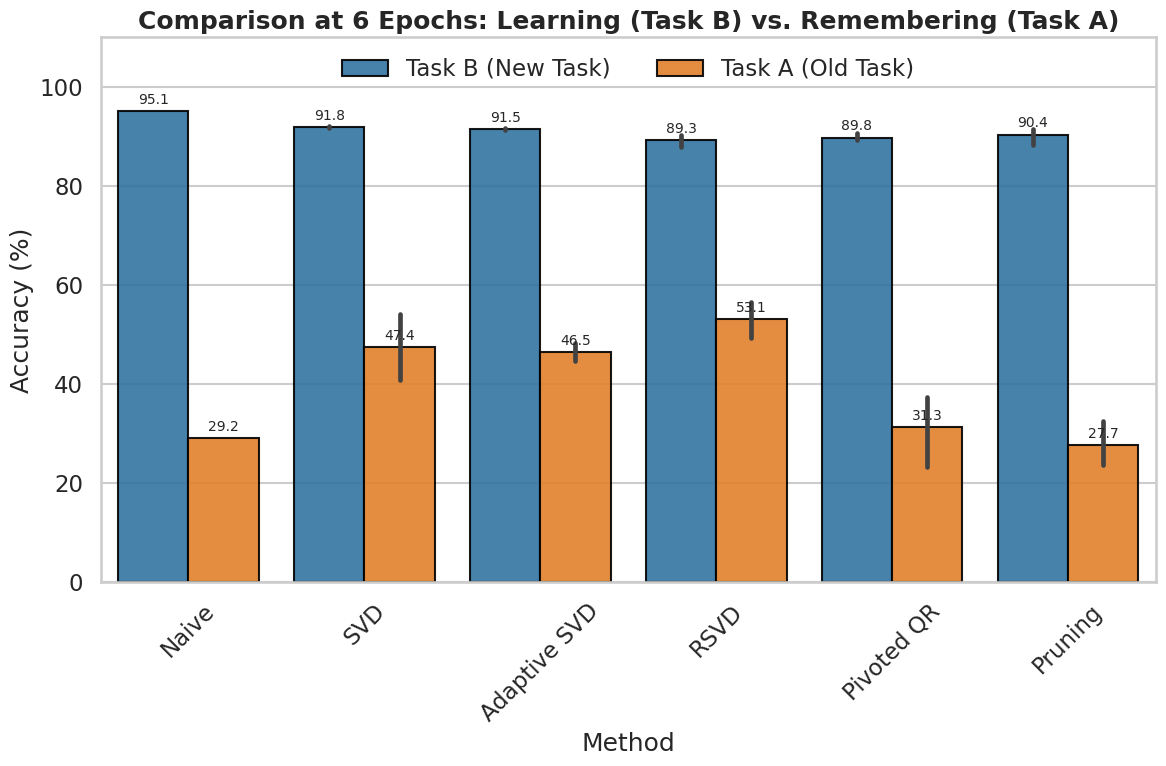

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Load and Prepare Data ---
df = pd.read_csv('main_experiment_results_inbar_220226.csv')

# Filter for exactly 4 Epochs
df_plot = df[df['Epochs'] == 6].copy()

# Melt the dataframe to get "Side-by-Side" bars easily in Seaborn
# This transforms columns into rows: (Method, Task Type, Accuracy)
df_melted = df_plot.melt(
    id_vars=['Method'],
    value_vars=['Task B Acc (Plasticity)', 'Task A Acc (Retention)'],
    var_name='Metric',
    value_name='Accuracy'
)

# Rename the metrics for the legend to be cleaner
df_melted['Metric'] = df_melted['Metric'].replace({
    'Task B Acc (Plasticity)': 'Task B (New Task)',
    'Task A Acc (Retention)': 'Task A (Old Task)'
})

# Set plot style
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams['font.family'] = 'sans-serif'

# --- Plot ---
plt.figure(figsize=(12, 8))

ax = sns.barplot(
    data=df_melted,
    x='Method',
    y='Accuracy',
    hue='Metric',
    palette=['#1f77b4', '#ff7f0e'], # Blue (Left) for Task B, Orange (Right) for Task A
    edgecolor="black",
    alpha=0.9
)

# Formatting
plt.title("Comparison at 6 Epochs: Learning (Task B) vs. Remembering (Task A)", fontweight='bold')
plt.ylabel("Accuracy (%)")
plt.xlabel("Method")
plt.ylim(0, 110) # Little extra room for legend
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.00), ncol=2, frameon=False)
plt.xticks(rotation=45)

# Add values on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3, fontsize=10)

plt.tight_layout()
plt.show()

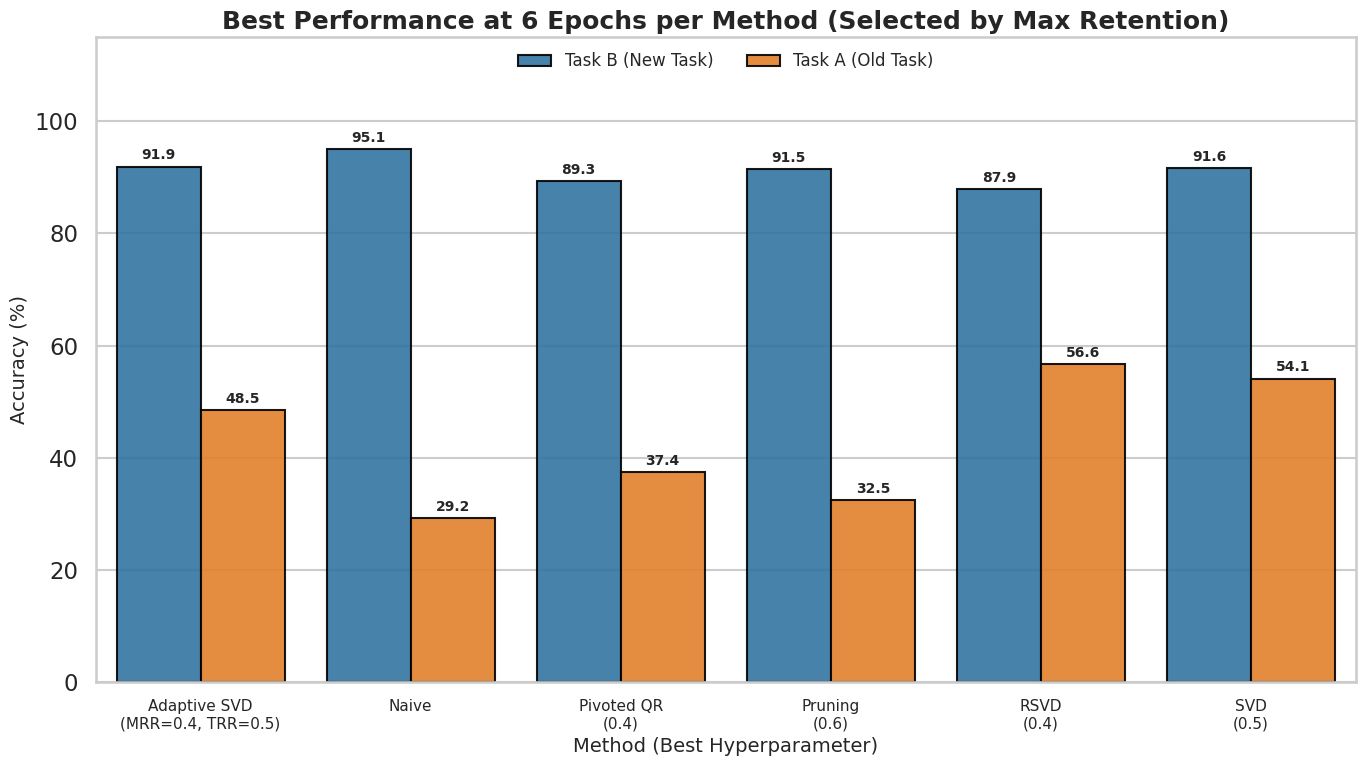

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Load and Prepare Data ---
df = pd.read_csv('main_experiment_results_inbar_220226.csv')

# 1. Filter for exactly 6 Epochs
df_6 = df[df['Epochs'] == 6].copy()

# 2. Identify the best hyperparameter result per Method (Highest Retention/Remembering)
# This finds the index of the row with the max Task A accuracy for each method
idx_best = df_6.groupby('Method')['Task A Acc (Retention)'].idxmax()
df_best = df_6.loc[idx_best].copy()

# 3. Create a descriptive label for the X-axis that includes the Hyperparameter
def create_label(row):
    method = row['Method']
    param = row['Hyperparam']
    if pd.isna(param) or param == 'N/A':
        return method
    return f"{method}\n({param})"

df_best['Method_Display'] = df_best.apply(create_label, axis=1)

# 4. Melt the dataframe for grouped bar plotting
df_melted = df_best.melt(
    id_vars=['Method_Display'],
    value_vars=['Task B Acc (Plasticity)', 'Task A Acc (Retention)'],
    var_name='Metric',
    value_name='Accuracy'
)

# Rename the metrics for the legend
df_melted['Metric'] = df_melted['Metric'].replace({
    'Task B Acc (Plasticity)': 'Task B (New Task)',
    'Task A Acc (Retention)': 'Task A (Old Task)'
})

# Set plot style
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams['font.family'] = 'sans-serif'

# --- Plot ---
plt.figure(figsize=(14, 8))

ax = sns.barplot(
    data=df_melted,
    x='Method_Display',
    y='Accuracy',
    hue='Metric',
    palette=['#1f77b4', '#ff7f0e'], # Blue for Plasticity, Orange for Retention
    edgecolor="black",
    alpha=0.9
)

# Formatting
plt.title("Best Performance at 6 Epochs per Method (Selected by Max Retention)", fontweight='bold', fontsize=18)
plt.ylabel("Accuracy (%)", fontsize=14)
plt.xlabel("Method (Best Hyperparameter)", fontsize=14)
plt.ylim(0, 115)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.0), ncol=2, frameon=False, fontsize=12)
plt.xticks(fontsize=11)

# Add values on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3, fontsize=10, weight='bold')

plt.tight_layout()
plt.savefig('best_results_6_epochs.png', dpi=300)

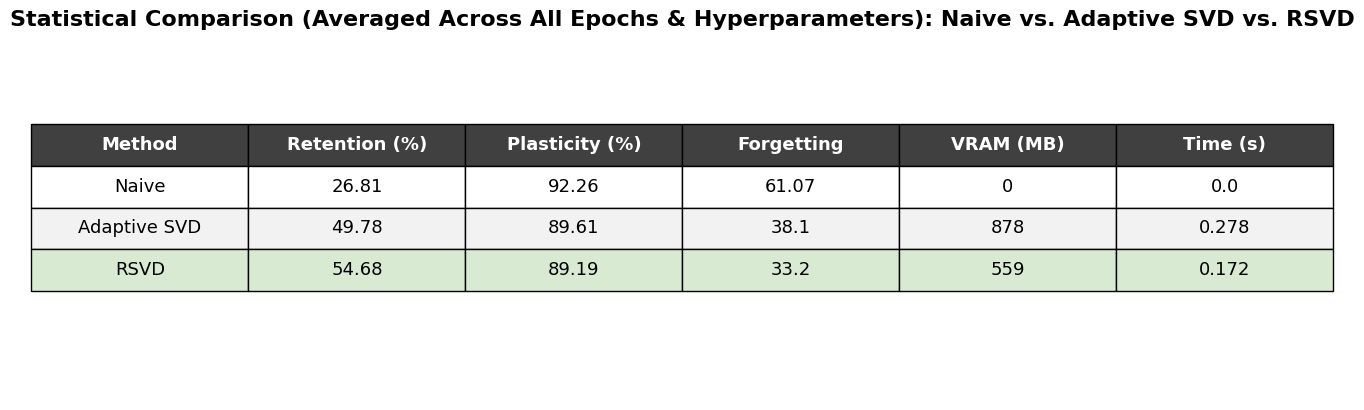

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Load and Prepare Data ---
df = pd.read_csv('main_experiment_results_inbar_220226.csv')

# Filtering for the specific methods.
# We include all hyperparameters and all epochs for these methods to average them.
df_filtered = df[df['Method'].isin(['Naive', 'Adaptive SVD', 'RSVD'])].copy()

# Group by Method and calculate the mean across all epochs AND all hyperparameters
metrics = ['Task A Acc (Retention)', 'Task B Acc (Plasticity)', 'Forgetting', 'Peak VRAM (MB)', 'Prep Time (s)']
df_avg = df_filtered.groupby('Method')[metrics].mean().reset_index()

# Reorder to match: Naive -> Adaptive SVD -> RSVD
method_order = ['Naive', 'Adaptive SVD', 'RSVD']
df_avg['Method'] = pd.Categorical(df_avg['Method'], categories=method_order, ordered=True)
df_avg = df_avg.sort_values('Method')

# Select and Rename Columns
cols_map = {
    'Method': 'Method',
    'Task A Acc (Retention)': 'Retention (%)',
    'Task B Acc (Plasticity)': 'Plasticity (%)',
    'Forgetting': 'Forgetting',
    'Peak VRAM (MB)': 'VRAM (MB)',
    'Prep Time (s)': 'Time (s)'
}
df_view = df_avg.rename(columns=cols_map)

# Formatting numbers
df_view['Retention (%)'] = df_view['Retention (%)'].round(2)
df_view['Plasticity (%)'] = df_view['Plasticity (%)'].round(2)
df_view['Forgetting'] = df_view['Forgetting'].round(2)
df_view['VRAM (MB)'] = df_view['VRAM (MB)'].round(0).fillna(0).astype(int)
df_view['Time (s)'] = df_view['Time (s)'].round(3)

# --- Create Visual Table ---
fig, ax = plt.subplots(figsize=(14, 5))
ax.axis('tight')
ax.axis('off')

# Prepare data list
header = df_view.columns.to_list()
data = df_view.values.tolist()
table_content = [header] + data

# Draw Table
table = ax.table(
    cellText=table_content,
    colLabels=None,
    cellLoc='center',
    loc='center'
)

# Styling
table.auto_set_font_size(False)
table.set_fontsize(13)
table.scale(1.2, 2.5) # Make cells taller and wider

# --- Row Specific Styling ---
for col_idx in range(len(header)):
    # Row 0: Header (Dark Grey)
    table[(0, col_idx)].set_facecolor('#404040')
    table[(0, col_idx)].set_text_props(color='white', weight='bold')

    # Row 1: Naive (White)
    table[(1, col_idx)].set_facecolor('#ffffff')

    # Row 2: Adaptive SVD (Light Grey)
    table[(2, col_idx)].set_facecolor('#f2f2f2')

    # Row 3: RSVD (Winner - Light Green)
    table[(3, col_idx)].set_facecolor('#d9ead3')

# Updated Title to reflect full averaging
plt.title("Statistical Comparison (Averaged Across All Epochs & Hyperparameters): Naive vs. Adaptive SVD vs. RSVD",
          fontweight='bold', fontsize=16, y=0.95)

plt.savefig('comparison_table_avg_full.png', bbox_inches='tight', dpi=300)
plt.show()